In [1]:
import json_helper

In [2]:
import os

noaa_token = os.getenv('NOAA_TOKEN')
if noaa_token:
    print('NOAA_TOKEN found: fetching latest data from NOAA API, then loading DataFrame.')
    df_daily_summaries = json_helper.fetch_and_load_daily_summaries_dataframe(token=noaa_token)
else:
    print('NOAA_TOKEN not set: loading DataFrame from local JSON files only.')
    df_daily_summaries = json_helper.load_json_files_to_dataframe()

print(f'df_daily_summaries rows: {len(df_daily_summaries)}')

NOAA_TOKEN not set: loading DataFrame from local JSON files only.
Found 2 JSON files
Loaded 550 records into DataFrame
df_daily_summaries rows: 550


In [3]:
# display a summary of df_daily_summaries
df_daily_summaries.info()
print("\nFirst few rows:")
print(df_daily_summaries.head())

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        550 non-null    str  
 1   datatype    550 non-null    str  
 2   station     550 non-null    str  
 3   attributes  550 non-null    str  
 4   value       550 non-null    int64
dtypes: int64(1), str(4)
memory usage: 21.6 KB

First few rows:
                  date datatype            station attributes  value
0  2018-01-01T00:00:00     ADPT  GHCND:USW00013781       ,,W,   -178
1  2018-01-01T00:00:00     ASLP  GHCND:USW00013781       ,,W,  10312
2  2018-01-01T00:00:00     ASTP  GHCND:USW00013781       ,,W,  10274
3  2018-01-01T00:00:00     AWBT  GHCND:USW00013781       ,,W,   -122
4  2018-01-01T00:00:00     AWND  GHCND:USW00013781       ,,W,     42


How many stations are there in total for FIPS10003

In [4]:
# Count unique weather stations represented in this location/time slice
num_stations = df_daily_summaries['station'].dropna().nunique()
print(f"Number of stations for FIPS10003: {num_stations}")

Number of stations for FIPS10003: 1


Create a DataFrame called temps_max that only contains the entries from df_daily_summaries where the datatype column is equal to TMAX. This DataFrame should only retain the date column and the value column.

In [3]:
# 
temps_max = df_daily_summaries[df_daily_summaries['datatype'] == 'TMAX'][['date', 'value']].reset_index(drop=True)

In [6]:
temps_max

,date,value
0,2018-01-01T00:00:00,-60
1,2018-01-02T00:00:00,-38
2,2018-01-03T00:00:00,-5
3,2018-01-04T00:00:00,-21
4,2018-01-05T00:00:00,-82
5,2018-01-06T00:00:00,-88
6,2018-01-07T00:00:00,-71
7,2018-01-08T00:00:00,6
8,2018-01-09T00:00:00,78
9,2018-01-10T00:00:00,56


How many entries are there in the temps_max DataFrame? What are the mean, min, and max values?

In [7]:
# 
print(f"Number of entries: {len(temps_max)}")
print(f"Mean value: {temps_max['value'].mean():.2f}")
print(f"Min value: {temps_max['value'].min()}")
print(f"Max value: {temps_max['value'].max()}")

Number of entries: 31
Mean value: 48.19
Min value: -88
Max value: 172


Let's graph this DataFrame so we can get a visual representation for this information.

In [4]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [5]:
%matplotlib inline

In [6]:
x = temps_max['date'].str[8:10]
y = temps_max['value'] / 10

[Text(0.5, 0, 'day of month'),
 Text(0, 0.5, 'temperature in celsius'),
 Text(0.5, 1.0, 'Max Temperatues Jan 2018')]

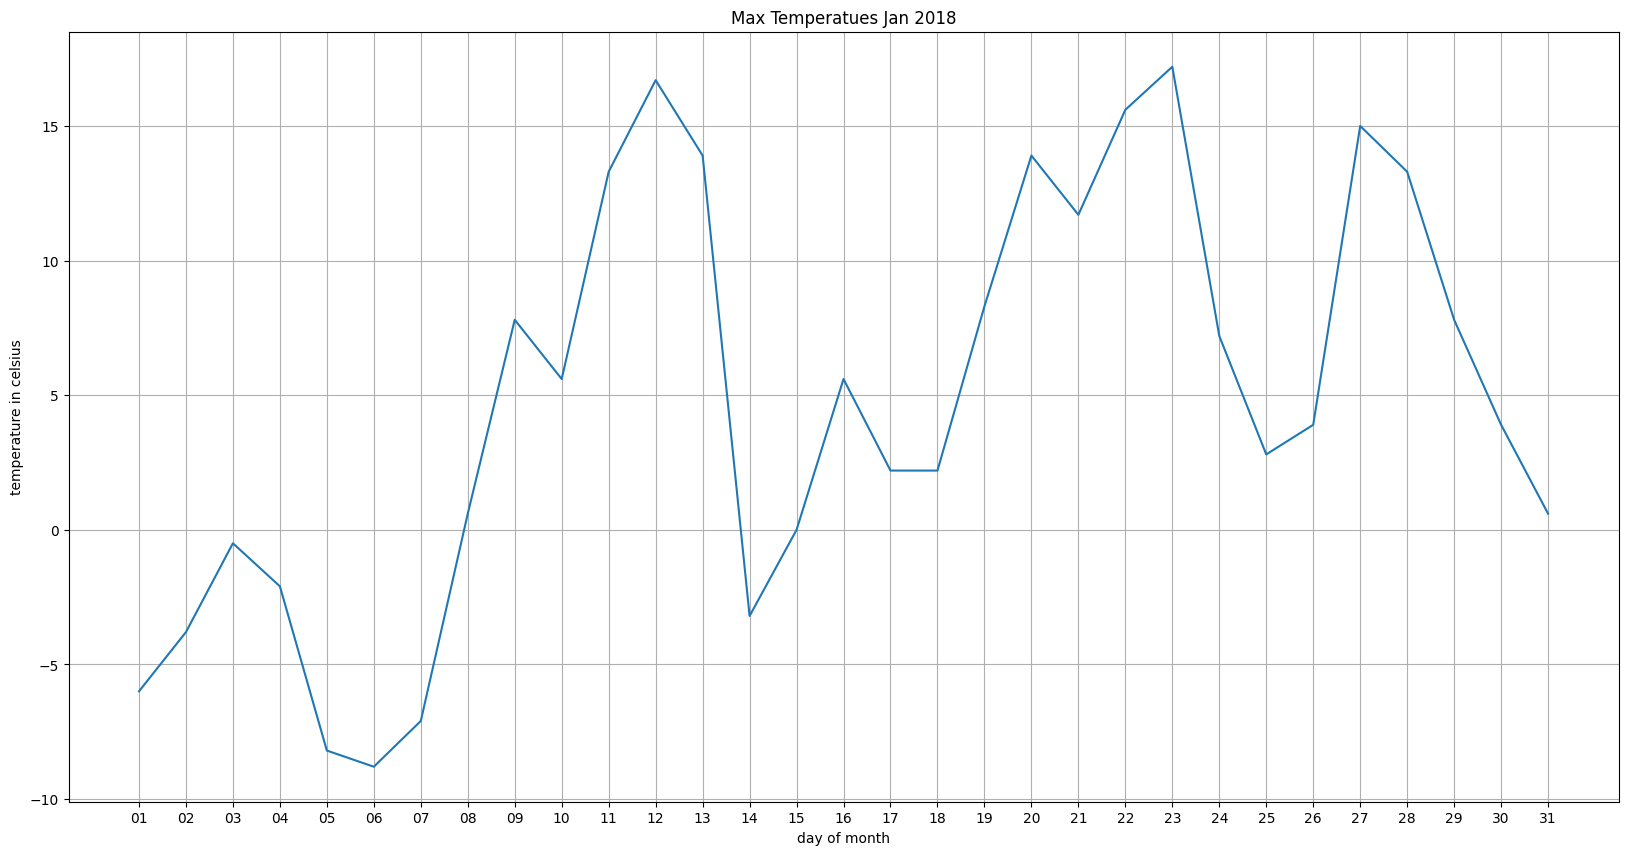

In [7]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 10)
ax.plot(x, y)
ax.grid()
ax.set(xlabel='day of month', ylabel='temperature in celsius', title='Max Temperatues Jan 2018')

Create a DataFrame called temps_min that only contains the entries from df_daily_summaries where the datatype column is equal to TMIN. This DataFrame should only retain the date column and the value column.

In [8]:
# 
temps_min = df_daily_summaries[df_daily_summaries['datatype'] == 'TMIN'][['date', 'value']].reset_index(drop=True)

In [ ]:
temps_min

How many entries are there in the temps_min DataFrame? What are the mean, min, and max values?

In [9]:
# 
print(f"Number of entries: {len(temps_min)}")
print(f"Mean value: {temps_min['value'].mean():.2f}")
print(f"Min value: {temps_min['value'].min()}")
print(f"Max value: {temps_min['value'].max()}")

Number of entries: 31
Mean value: -55.23
Min value: -166
Max value: 83


Graph the temps_min DataFrame

[Text(0.5, 0, 'day of month'),
 Text(0, 0.5, 'temperature in celsius'),
 Text(0.5, 1.0, 'Min Temperatures Jan 2018')]

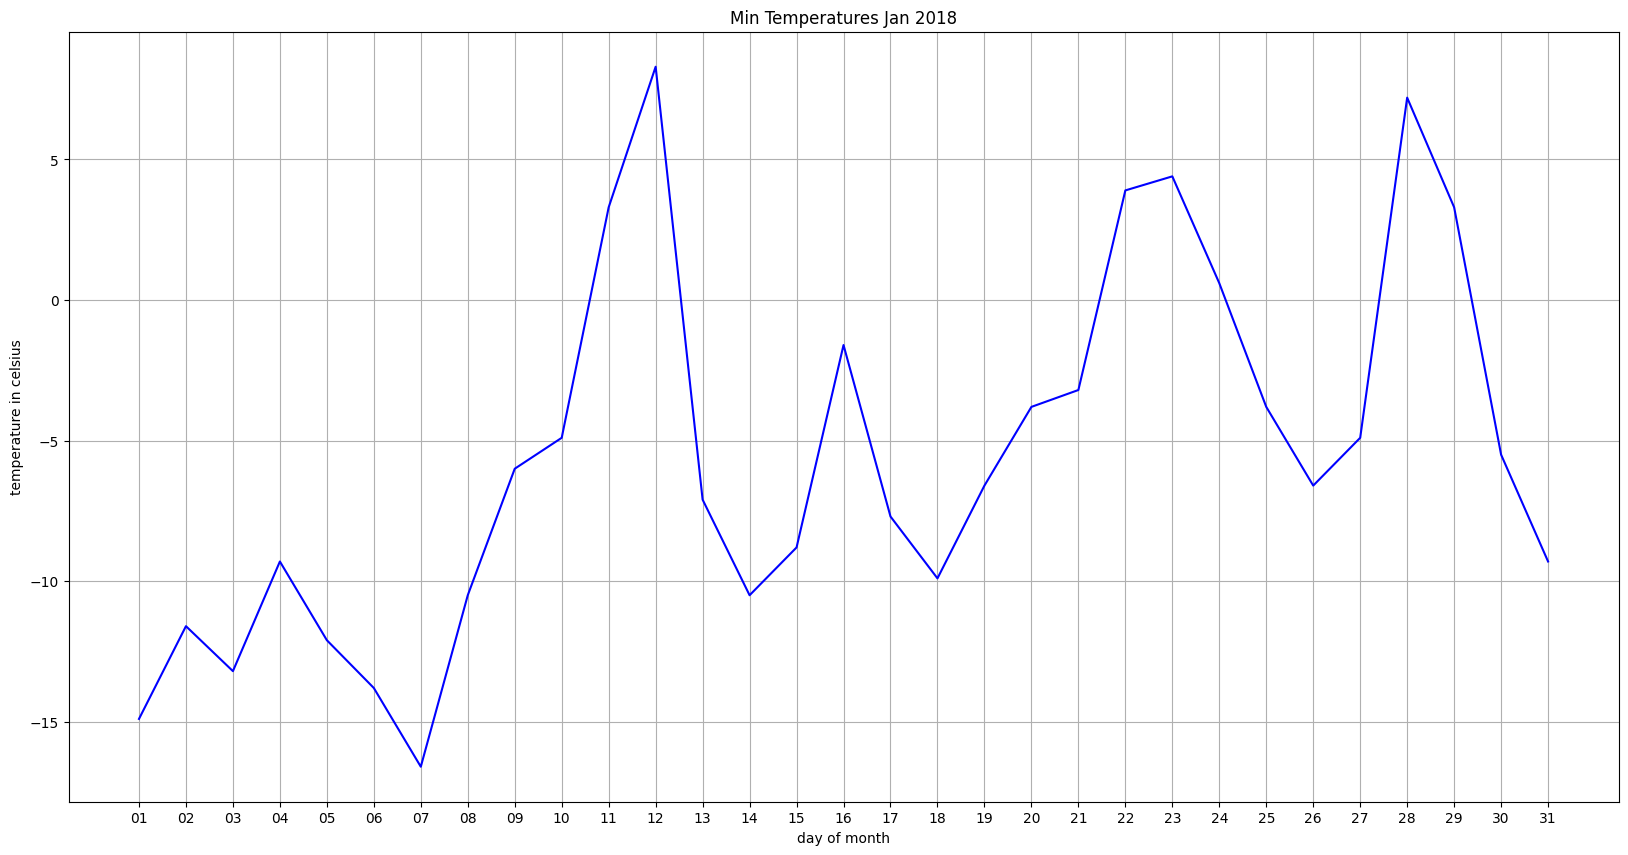

In [10]:
# 
fig, ax = plt.subplots()
fig.set_size_inches(20, 10)
ax.plot(x, temps_min['value'] / 10, color='blue')
ax.grid()
ax.set(xlabel='day of month', ylabel='temperature in celsius', title='Min Temperatures Jan 2018')

We can also plot both of these lines in the same graph.

[Text(0.5, 0, 'day of month'),
 Text(0, 0.5, 'temperature in celsius'),
 Text(0.5, 1.0, 'Min & Max Temperatues Jan 2018')]

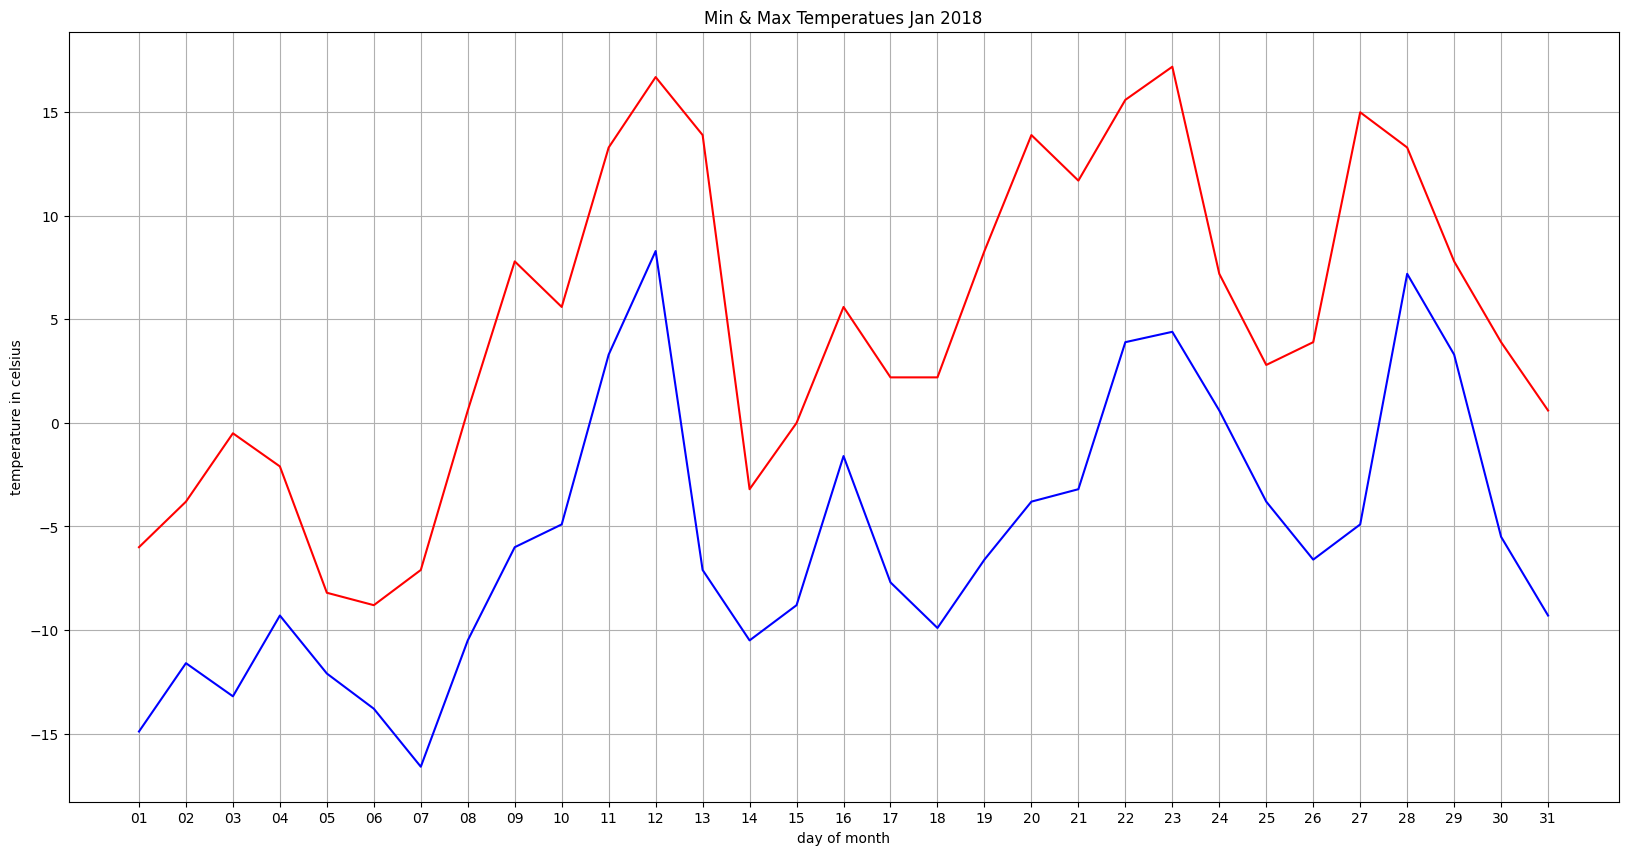

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 10)
ax.plot(x, temps_max['value'] / 10, color='red')
ax.plot(x, temps_min['value'] / 10, color='blue')
ax.grid()
ax.set(xlabel='day of month', ylabel='temperature in celsius', title='Min & Max Temperatues Jan 2018')